# Credit-Card Anomaly Detection

Goal: rank unusual future transactions without using fraud labels while fitting.

## 1. Setup

In [1]:
# Imports, fixed settings, and reproducibility.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.preprocessing import RobustScaler

RANDOM_STATE = 42
DATA_PATH = Path("data/creditcard.csv")
FIT_FRACTION = 0.80          # Earlier 80% of time: allowed for fitting.
REVIEW_RATE = 0.005          # Later: manually review the top 0.5%.
SVM_FIT_SAMPLE_SIZE = 20_000 # Used later because kernel SVMs are expensive.

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 40)

print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

pandas: 2.3.3
scikit-learn: 1.9.1


## 2. Load, inspect, and split by time

In [2]:
# Load raw data. `Class` is held aside and never enters a fitted transformer/model.
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. Download it with:\\n"
        "kaggle datasets download -d mlg-ulb/creditcardfraud -p data --unzip"
    )

transactions = pd.read_csv(DATA_PATH)
required_columns = {"Time", "Amount", "Class"}
missing_columns = required_columns - set(transactions.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

audit = pd.Series({
    "rows": len(transactions),
    "columns": transactions.shape[1],
    "missing_values": int(transactions.isna().sum().sum()),
    "duplicate_rows": int(transactions.duplicated().sum()),
    "start_time_seconds": transactions["Time"].min(),
    "end_time_seconds": transactions["Time"].max(),
})
display(audit.to_frame("value"))
display(transactions.head())

,value
rows,284807.0
columns,31.0
missing_values,0.0
duplicate_rows,1081.0
start_time_seconds,0.0
end_time_seconds,172792.0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


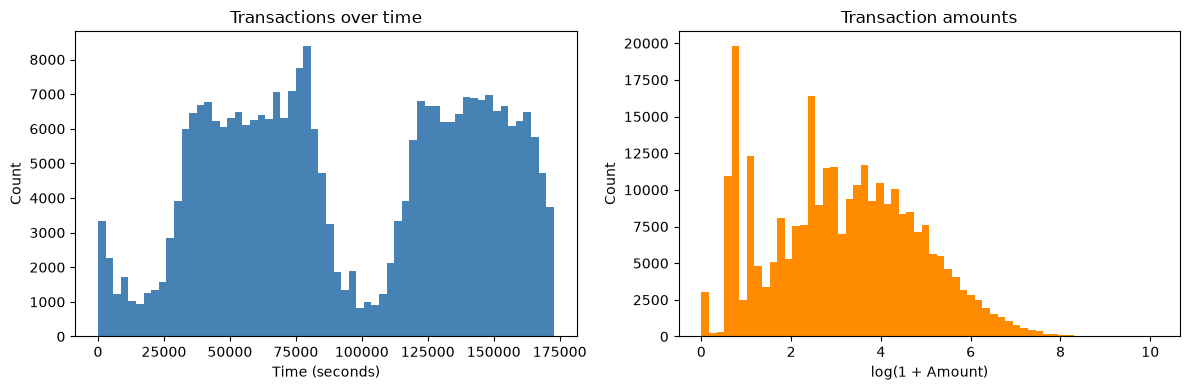

In [3]:
# Inspect the two non-PCA-like features; log scale makes transaction amounts readable.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(transactions["Time"], bins=60, color="steelblue")
axes[0].set(title="Transactions over time", xlabel="Time (seconds)", ylabel="Count")
axes[1].hist(np.log1p(transactions["Amount"]), bins=60, color="darkorange")
axes[1].set(title="Transaction amounts", xlabel="log(1 + Amount)", ylabel="Count")
plt.tight_layout()
plt.show()

In [4]:
# Chronological hold-out: models see only earlier transactions.
transactions = transactions.sort_values("Time").reset_index(drop=True)
split_index = int(len(transactions) * FIT_FRACTION)

X = transactions.drop(columns="Class")
y_reference = transactions["Class"].copy()  # Do not inspect/use until evaluation.
X_fit_raw = X.iloc[:split_index].copy()
X_score_raw = X.iloc[split_index:].copy()
y_score_reference = y_reference.iloc[split_index:].copy()

split_summary = pd.DataFrame({
    "rows": [len(X_fit_raw), len(X_score_raw)],
    "time_start": [X_fit_raw["Time"].min(), X_score_raw["Time"].min()],
    "time_end": [X_fit_raw["Time"].max(), X_score_raw["Time"].max()],
}, index=["fit (earlier)", "score (later)"])
display(split_summary)
print(f"Review budget: {REVIEW_RATE:.1%} of later transactions = {int(np.ceil(len(X_score_raw) * REVIEW_RATE)):,} reviews")

,rows,time_start,time_end
fit (earlier),227845,0.0,145247.0
score (later),56962,145248.0,172792.0


Review budget: 0.5% of later transactions = 285 reviews


## 3. Prepare features

In [5]:
# Robust scaling limits the influence of extreme values. Fit only on the earlier block.
feature_names = X_fit_raw.columns.tolist()
preprocessor = RobustScaler()

X_fit = pd.DataFrame(
    preprocessor.fit_transform(X_fit_raw),
    columns=feature_names,
    index=X_fit_raw.index,
)
X_score = pd.DataFrame(
    preprocessor.transform(X_score_raw),
    columns=feature_names,
    index=X_score_raw.index,
)

assert X_fit.columns.equals(X_score.columns)
assert not X_fit.isna().any().any() and not X_score.isna().any().any()
print(f"Prepared fit matrix: {X_fit.shape}")
print(f"Prepared scoring matrix: {X_score.shape}")

Prepared fit matrix: (227845, 30)
Prepared scoring matrix: (56962, 30)


## 4. Fit and evaluate models

In [6]:
# Learn normal patterns from earlier transactions only.
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
isolation_forest.fit(X_fit)

# `score_samples` is higher for normal points, so negate it:
# higher anomaly_score = more suspicious transaction.
score_results = X_score_raw[["Time", "Amount"]].copy()
score_results["anomaly_score"] = -isolation_forest.score_samples(X_score)

# Rank transactions and select exactly the fixed review budget.
review_count = int(np.ceil(len(score_results) * REVIEW_RATE))
score_results["suspicion_rank"] = (
    score_results["anomaly_score"]
    .rank(method="first", ascending=False)
    .astype(int)
)
score_results["review"] = score_results["suspicion_rank"] <= review_count

assert score_results["review"].sum() == review_count

print(f"Transactions selected for review: {review_count:,}")
print(
    "Score cutoff: "
    f"{score_results.loc[score_results['review'], 'anomaly_score'].min():.4f}"
)

display(score_results.sort_values("suspicion_rank").head(10))

Transactions selected for review: 285
Score cutoff: 0.6031


,Time,Amount,anomaly_score,suspicion_rank,review
274771,166198.0,25691.16,0.776006,1,True
231455,146772.0,3552.96,0.739089,2,True
262378,160444.0,2074.69,0.731158,3,True
262843,160672.0,1441.06,0.726925,4,True
262838,160669.0,1441.06,0.726727,5,True
228158,145381.0,8182.70,0.724242,6,True
244674,152443.0,3758.25,0.723569,7,True
229859,146082.0,2687.48,0.721115,8,True
261843,160204.0,1441.06,0.720504,9,True
232014,147012.0,1201.93,0.716550,10,True


In [7]:
# Evaluate the fixed Isolation Forest ranking using the hidden reference label.
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
)

evaluation = score_results.copy()
evaluation["is_fraud"] = y_score_reference

# Quality at our fixed capacity: the 285 transactions selected for review.
precision_at_budget = evaluation.loc[evaluation["review"], "is_fraud"].mean()
fraud_found = evaluation.loc[evaluation["review"], "is_fraud"].sum()
total_fraud_later = evaluation["is_fraud"].sum()

# Whole-ranking metrics: higher anomaly_score should rank fraud above normal transactions.
average_precision = average_precision_score(
    evaluation["is_fraud"],
    evaluation["anomaly_score"],
)
roc_auc = roc_auc_score(
    evaluation["is_fraud"],
    evaluation["anomaly_score"],
)

print(f"Fraud found in {review_count:,} reviews: {fraud_found:,}")
print(f"Precision at review budget: {precision_at_budget:.2%}")
print(f"Later fraud captured: {fraud_found:,} / {total_fraud_later:,}")
print(f"Average precision (PR-AUC): {average_precision:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

display(
    evaluation.loc[evaluation["review"]]
    .sort_values("suspicion_rank")
    .head(10)
)

Fraud found in 285 reviews: 14
Precision at review budget: 4.91%
Later fraud captured: 14 / 75
Average precision (PR-AUC): 0.0427
ROC-AUC: 0.9500


,Time,Amount,anomaly_score,suspicion_rank,review,is_fraud
274771,166198.0,25691.16,0.776006,1,True,0
231455,146772.0,3552.96,0.739089,2,True,0
262378,160444.0,2074.69,0.731158,3,True,0
262843,160672.0,1441.06,0.726925,4,True,0
262838,160669.0,1441.06,0.726727,5,True,0
228158,145381.0,8182.70,0.724242,6,True,0
244674,152443.0,3758.25,0.723569,7,True,0
229859,146082.0,2687.48,0.721115,8,True,0
261843,160204.0,1441.06,0.720504,9,True,0
232014,147012.0,1201.93,0.716550,10,True,0


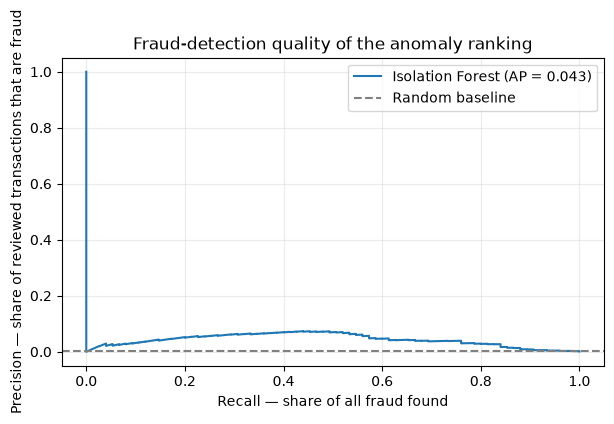

In [8]:
# Precision-recall curve: useful because fraud is rare.
precision, recall, _ = precision_recall_curve(
    evaluation["is_fraud"],
    evaluation["anomaly_score"],
)

plt.figure(figsize=(7, 4))
plt.plot(recall, precision, label=f"Isolation Forest (AP = {average_precision:.3f})")
plt.axhline(
    evaluation["is_fraud"].mean(),
    color="gray",
    linestyle="--",
    label="Random baseline",
)
plt.xlabel("Recall — share of all fraud found")
plt.ylabel("Precision — share of reviewed transactions that are fraud")
plt.title("Fraud-detection quality of the anomaly ranking")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [9]:
# LOF: a transaction is suspicious if it is much less dense
# than the transactions in its local neighborhood.
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import average_precision_score, roc_auc_score

lof = LocalOutlierFactor(
    n_neighbors=35,
    novelty=True,          # Fit on earlier data, score separate later data.
    contamination="auto",
    n_jobs=-1,
)

# Use arrays here because LOF's neighbor search does not preserve feature names.
# Fit only on earlier transactions. No Class labels are used.
lof.fit(X_fit.to_numpy())

# LOF's original score is higher for normal points.
# Negate it so that higher = more suspicious, like Isolation Forest.
lof_results = X_score_raw[["Time", "Amount"]].copy()
lof_results["anomaly_score"] = -lof.score_samples(X_score.to_numpy())

# Use the same review capacity: exactly 285 transactions.
lof_results["suspicion_rank"] = (
    lof_results["anomaly_score"]
    .rank(method="first", ascending=False)
    .astype(int)
)
lof_results["review"] = lof_results["suspicion_rank"] <= review_count

# Only now reveal labels to evaluate this already-fitted ranking.
lof_results["is_fraud"] = y_score_reference

lof_fraud_found = lof_results.loc[lof_results["review"], "is_fraud"].sum()
lof_precision_at_budget = lof_results.loc[lof_results["review"], "is_fraud"].mean()
lof_average_precision = average_precision_score(
    lof_results["is_fraud"],
    lof_results["anomaly_score"],
)
lof_roc_auc = roc_auc_score(
    lof_results["is_fraud"],
    lof_results["anomaly_score"],
)

print(f"Fraud found in {review_count:,} reviews: {lof_fraud_found:,}")
print(f"Precision at review budget: {lof_precision_at_budget:.2%}")
print(f"Average precision (PR-AUC): {lof_average_precision:.4f}")
print(f"ROC-AUC: {lof_roc_auc:.4f}")

display(lof_results.sort_values("suspicion_rank").head(10))

Fraud found in 285 reviews: 0
Precision at review budget: 0.00%
Average precision (PR-AUC): 0.0030
ROC-AUC: 0.6341


,Time,Amount,anomaly_score,suspicion_rank,review,is_fraud
242878,151696.0,1.51,1536.128381,1,True,0
233781,147702.0,5.00,1191.457991,2,True,0
266933,162543.0,1.00,896.796214,3,True,0
279924,169180.0,56.60,26.696667,4,True,0
246284,153113.0,1.99,23.932177,5,True,0
237187,149132.0,21.00,22.208010,6,True,0
230098,146186.0,0.76,15.574122,7,True,0
274856,166244.0,31.01,14.355980,8,True,0
283051,171337.0,22.85,13.805185,9,True,0
259438,159117.0,0.90,13.000134,10,True,0


In [10]:
# One-Class SVM: learn a boundary around "normal" earlier transactions.
# It is expensive, so train it on a fixed random sample of 20,000 rows.
from sklearn.svm import OneClassSVM
from sklearn.metrics import average_precision_score, roc_auc_score

svm_fit_sample = X_fit.sample(
    n=min(SVM_FIT_SAMPLE_SIZE, len(X_fit)),
    random_state=RANDOM_STATE,
)

one_class_svm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.005,       # Expected upper bound for unusual points in fit data.
    cache_size=1000,
)

# Fit without fraud labels.
one_class_svm.fit(svm_fit_sample)

# Higher original score = more normal, so negate for "higher = suspicious".
svm_results = X_score_raw[["Time", "Amount"]].copy()
svm_results["anomaly_score"] = -one_class_svm.score_samples(X_score)

# Select exactly the same 285 transactions for review.
svm_results["suspicion_rank"] = (
    svm_results["anomaly_score"]
    .rank(method="first", ascending=False)
    .astype(int)
)
svm_results["review"] = svm_results["suspicion_rank"] <= review_count

# Reveal Class only after fitting and ranking.
svm_results["is_fraud"] = y_score_reference

svm_fraud_found = svm_results.loc[svm_results["review"], "is_fraud"].sum()
svm_precision_at_budget = svm_results.loc[svm_results["review"], "is_fraud"].mean()
svm_average_precision = average_precision_score(
    svm_results["is_fraud"],
    svm_results["anomaly_score"],
)
svm_roc_auc = roc_auc_score(
    svm_results["is_fraud"],
    svm_results["anomaly_score"],
)

print(f"Fraud found in {review_count:,} reviews: {svm_fraud_found:,}")
print(f"Precision at review budget: {svm_precision_at_budget:.2%}")
print(f"Average precision (PR-AUC): {svm_average_precision:.4f}")
print(f"ROC-AUC: {svm_roc_auc:.4f}")

display(svm_results.sort_values("suspicion_rank").head(10))

Fraud found in 285 reviews: 22
Precision at review budget: 7.72%
Average precision (PR-AUC): 0.0473
ROC-AUC: 0.9319


,Time,Amount,anomaly_score,suspicion_rank,review,is_fraud
227921,145283.0,10000.00,-0.0,1,True,0
228158,145381.0,8182.70,-0.0,2,True,0
228723,145630.0,7367.00,-0.0,3,True,0
229034,145773.0,1210.00,-0.0,4,True,0
229859,146082.0,2687.48,-0.0,5,True,0
231455,146772.0,3552.96,-0.0,6,True,0
233904,147747.0,12.31,-0.0,7,True,0
238256,149594.0,538.00,-0.0,8,True,0
238966,149898.0,247.00,-0.0,9,True,0
243702,152037.0,430.00,-0.0,10,True,0


## 5. Compare models

All models use the same time split and 285-review budget. Higher precision at 285 is better.

In [11]:
# Compare the already-fitted models; no parameters are changed after evaluation.
model_results = pd.DataFrame(
    {
        "model": ["Isolation Forest", "LOF", "One-Class SVM"],
        "fraud_found_at_285": [fraud_found, lof_fraud_found, svm_fraud_found],
        "precision_at_285": [
            precision_at_budget,
            lof_precision_at_budget,
            svm_precision_at_budget,
        ],
        "recall_at_285": [
            fraud_found / total_fraud_later,
            lof_fraud_found / total_fraud_later,
            svm_fraud_found / total_fraud_later,
        ],
        "pr_auc": [average_precision, lof_average_precision, svm_average_precision],
        "roc_auc": [roc_auc, lof_roc_auc, svm_roc_auc],
    }
).sort_values("precision_at_285", ascending=False)

display(model_results.round(4))
print("Conclusion: One-Class SVM finds the most fraud within the fixed review budget.")

,model,fraud_found_at_285,precision_at_285,recall_at_285,pr_auc,roc_auc
2,One-Class SVM,22,0.0772,0.2933,0.0473,0.9319
0,Isolation Forest,14,0.0491,0.1867,0.0427,0.9500
1,LOF,0,0.0000,0.0000,0.0030,0.6341


Conclusion: One-Class SVM finds the most fraud within the fixed review budget.


**Conclusion.** One-Class SVM found 22 of 75 later fraud cases in 285 reviews (7.72% precision). It is the best model for this fixed review budget, while Isolation Forest remains the faster baseline. Anomaly scores prioritize review; they are not fraud probabilities.